# Introduction to Data Analysis and Modeling with Python

In this notebook, we will learn the first steps that data scientists and machine learning engineers use when working with numerical data.

We will practice:

- Loading a dataset
- Inspecting the data
- Cleaning missing values
- Using NumPy and Pandas
- Visualizing data
- Finding correlations
- Filtering data
- Fitting simple models
- Evaluating model performance
- Making predictions

By the end, you should understand the basic workflow used before building machine learning models.

We use:

- `pandas` to load and organize data
- `numpy` for numerical calculations
- `matplotlib` for plotting

In [1]:
# Although there are some exceptions, it is generally a good idea to keep all of your
# imports in one place so that you can easily manage them. Doing so also makes it easy
# to copy all of them at once and paste them into a new notebook you are starting.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Loading the Dataset

The first step in any data analysis project is loading the data.

Our dataset contains yearly GDP values for different countries.

If you open the CSV file, you will notice that the first 4 rows contain extra information that is not part of the actual data table. Because of this, we use `skiprows=4`.

In [2]:
gdp = pd.read_csv("GDP_Data.csv", delimiter=",", skiprows=4) # Make sure the csv file and notebook are in the same folder, or provide the full path to the csv file.

gdp.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Unnamed: 67
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.791061e+09,2.963128e+09,2.983799e+09,3.092179e+09,3.276188e+09,3.395794e+09,2.610039e+09,3.126019e+09,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP (current US$),NY.GDP.MKTP.CD,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,...,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12,NaN
2,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,...,2.055058e+10,1.999814e+10,1.801955e+10,1.889635e+10,1.841886e+10,1.890450e+10,2.014345e+10,1.458314e+10,NaN,NaN
3,Africa Western and Central,AFW,GDP (current US$),NY.GDP.MKTP.CD,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,...,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11,NaN
4,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.372444e+11,8.721930e+10,4.984049e+10,6.897277e+10,7.779294e+10,6.930911e+10,5.024137e+10,6.568544e+10,1.067136e+11,NaN


`head()` shows the first few rows of the dataset. This helps us check that the file loaded correctly.

## 2. First Look at the Data

Before doing any analysis, we should understand what kind of data we have.

Important questions:

- How many rows and columns are there?
- What are the column names?
- Which columns are numerical?
- Are there missing values?
- What are the minimum, maximum, mean, and standard deviation?

In [3]:
gdp.shape

(266, 68)

In [4]:
gdp.columns

Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       'Unnamed: 67'],
      dtype='str')

In [5]:
gdp.info()

<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 68 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country Name    266 non-null    str    
 1   Country Code    266 non-null    str    
 2   Indicator Name  266 non-null    str    
 3   Indicator Code  266 non-null    str    
 4   1960            132 non-null    float64
 5   1961            134 non-null    float64
 6   1962            136 non-null    float64
 7   1963            136 non-null    float64
 8   1964            136 non-null    float64
 9   1965            147 non-null    float64
 10  1966            150 non-null    float64
 11  1967            153 non-null    float64
 12  1968            158 non-null    float64
 13  1969            158 non-null    float64
 14  1970            167 non-null    float64
 15  1971            170 non-null    float64
 16  1972            170 non-null    float64
 17  1973            170 non-null    float64
 18  1

In [6]:
gdp.describe()

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,Unnamed: 67
count,1.320000e+02,1.340000e+02,1.360000e+02,1.360000e+02,1.360000e+02,1.470000e+02,1.500000e+02,1.530000e+02,1.580000e+02,1.580000e+02,...,2.600000e+02,2.580000e+02,2.580000e+02,2.580000e+02,2.580000e+02,2.570000e+02,2.570000e+02,2.510000e+02,2.330000e+02,0.0
mean,7.127083e+10,7.274846e+10,7.639516e+10,8.236303e+10,9.048173e+10,9.182705e+10,1.021722e+11,1.059782e+11,1.111100e+11,1.228652e+11,...,2.540066e+12,2.401519e+12,2.435923e+12,2.611095e+12,2.773995e+12,2.826373e+12,2.739715e+12,3.211353e+12,3.599794e+12,NaN
std,2.135947e+11,2.223876e+11,2.370024e+11,2.549141e+11,2.788048e+11,2.927440e+11,3.205033e+11,3.389517e+11,3.608829e+11,3.971954e+11,...,8.604724e+12,8.165752e+12,8.306057e+12,8.840815e+12,9.410423e+12,9.564901e+12,9.318753e+12,1.072358e+13,1.147950e+13,NaN
min,1.201203e+07,1.159202e+07,9.122751e+06,1.084010e+07,1.271247e+07,1.359393e+07,1.446908e+07,1.583510e+07,1.460000e+07,1.585000e+07,...,3.876097e+07,3.681193e+07,4.162906e+07,4.527661e+07,4.801522e+07,5.412320e+07,5.174657e+07,6.019637e+07,6.034939e+07,NaN
25%,5.288385e+08,5.361919e+08,5.429342e+08,5.687581e+08,5.731182e+08,5.963705e+08,6.499792e+08,6.316797e+08,6.583150e+08,7.116598e+08,...,9.034786e+09,8.752203e+09,8.620796e+09,9.319389e+09,1.002804e+10,1.038167e+10,9.754600e+09,1.150202e+10,1.567158e+10,NaN
50%,3.040214e+09,2.965945e+09,3.049474e+09,3.569338e+09,3.432187e+09,3.120871e+09,3.549759e+09,3.384063e+09,3.950426e+09,4.526894e+09,...,5.339986e+10,4.966768e+10,4.980725e+10,5.400064e+10,5.614400e+10,6.028350e+10,5.370680e+10,6.568544e+10,8.227481e+10,NaN
75%,3.103045e+10,3.128542e+10,3.161860e+10,3.617095e+10,3.401420e+10,2.851910e+10,3.082854e+10,3.108639e+10,3.451917e+10,3.766365e+10,...,5.478564e+11,5.020845e+11,5.057567e+11,5.369244e+11,5.524163e+11,5.439767e+11,5.470542e+11,7.400410e+11,9.911146e+11,NaN
max,1.384857e+12,1.449221e+12,1.550815e+12,1.671447e+12,1.830492e+12,1.994103e+12,2.164118e+12,2.302577e+12,2.484674e+12,2.740499e+12,...,7.975652e+13,7.521506e+13,7.648645e+13,8.144205e+13,8.650222e+13,8.772810e+13,8.521515e+13,9.688240e+13,1.005620e+14,NaN


## 3. Finding Missing Values

Real-world datasets often contain missing values.

In Python, missing numerical values usually appear as `NaN`, which means “Not a Number.”

Before cleaning the data, we should check where those missing values are.

In [7]:
gdp.isna().sum()

Country Name        0
Country Code        0
Indicator Name      0
Indicator Code      0
1960              134
                 ... 
2019                9
2020                9
2021               15
2022               33
Unnamed: 67       266
Length: 68, dtype: int64

The dataset also contains a fully empty column at the end called something like `Unnamed: 67`.

If we use `dropna()` immediately, Python will remove every row because every row has a missing value in that empty column.

So we first remove fully empty and unnecessary columns, then remove rows that still contain missing values.

In [8]:
# Drop columns that are completely empty
gdp_clean = gdp.dropna(axis="columns", how="all")

# Remove unnecessary columns
gdp_clean = gdp_clean.drop(columns=["Country Code", "Indicator Name", "Indicator Code"])

# Drop rows that still contain missing values
gdp_clean = gdp_clean.dropna()

# Check result
gdp_clean.head()

,Country Name,1960,1961,1962,1963,1964,1965,1966,1967,1968,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
1,Africa Eastern and Southern,2.112502e+10,2.161623e+10,2.350628e+10,2.804836e+10,2.592067e+10,2.947210e+10,3.201437e+10,3.326951e+10,3.632779e+10,...,9.859871e+11,1.006526e+12,9.273485e+11,8.851764e+11,1.021043e+12,1.007196e+12,1.000834e+12,9.275933e+11,1.081998e+12,1.169484e+12
3,Africa Western and Central,1.044764e+10,1.117321e+10,1.199053e+10,1.272769e+10,1.389811e+10,1.492979e+10,1.591084e+10,1.451058e+10,1.496824e+10,...,8.339481e+11,8.943225e+11,7.686447e+11,6.913634e+11,6.848988e+11,7.670257e+11,8.225384e+11,7.864600e+11,8.444597e+11,8.778633e+11
13,Australia,1.860656e+10,1.968288e+10,1.992256e+10,2.153984e+10,2.380112e+10,2.597616e+10,2.730784e+10,3.044272e+10,3.271409e+10,...,1.576330e+12,1.467590e+12,1.350580e+12,1.206563e+12,1.326467e+12,1.428267e+12,1.392219e+12,1.326945e+12,1.552703e+12,1.675419e+12
14,Austria,6.592694e+09,7.311750e+09,7.756110e+09,8.374175e+09,9.169984e+09,9.994071e+09,1.088768e+10,1.157943e+10,1.244063e+10,...,4.301910e+11,4.425848e+11,3.819711e+11,3.958374e+11,4.172612e+11,4.549912e+11,4.446212e+11,4.352252e+11,4.803684e+11,4.714001e+11
16,Burundi,1.960000e+08,2.030000e+08,2.135000e+08,2.327500e+08,2.607500e+08,1.589950e+08,1.654446e+08,1.782971e+08,1.832000e+08,...,2.451607e+09,2.705783e+09,3.104004e+09,2.644488e+09,2.723587e+09,2.667182e+09,2.576519e+09,2.649680e+09,2.775799e+09,3.073415e+09


In [9]:
gdp_clean.shape

(122, 64)

In [10]:
gdp_clean.isna().sum()

Country Name    0
1960            0
1961            0
1962            0
1963            0
               ..
2018            0
2019            0
2020            0
2021            0
2022            0
Length: 64, dtype: int64

### Transposing the Dataset

Now that our dataset only contains:
- Country Name
- GDP values by year

We can transpose the data to better analyze trends over time.

After transposing:
- Rows → Years  
- Columns → Countries

In [11]:
# Transpose the dataset
gdp_transposed = gdp_clean.set_index("Country Name").T

# Convert index (years) to integers
gdp_transposed.index = gdp_transposed.index.astype(int)

# Check result
gdp_transposed.head()

Country Name,Africa Eastern and Southern,Africa Western and Central,Australia,Austria,Burundi,Belgium,Benin,Burkina Faso,Bangladesh,"Bahamas, The",...,Turkiye,Uganda,Upper middle income,Uruguay,United States,St. Vincent and the Grenadines,World,South Africa,Zambia,Zimbabwe
1960,2.112502e+10,1.044764e+10,1.860656e+10,6.592694e+09,1.960000e+08,1.165872e+10,2.261956e+08,3.304428e+08,4.274894e+09,1.698039e+08,...,7.552471e+09,4.230084e+08,2.293135e+11,1.242289e+09,5.433000e+11,1.306663e+07,1.384857e+12,8.748597e+09,7.130000e+08,1.052990e+09
1961,2.161623e+10,1.117321e+10,1.968288e+10,7.311750e+09,2.030000e+08,1.240015e+10,2.356682e+08,3.502472e+08,4.817580e+09,1.900980e+08,...,7.971175e+09,4.415241e+08,2.175573e+11,1.547389e+09,5.633000e+11,1.399996e+07,1.449221e+12,9.225996e+09,6.962857e+08,1.096647e+09
1962,2.350628e+10,1.199053e+10,1.992256e+10,7.756110e+09,2.135000e+08,1.326402e+10,2.364350e+08,3.795671e+08,5.081413e+09,2.122549e+08,...,8.902439e+09,4.490126e+08,2.231230e+11,1.710004e+09,6.051000e+11,1.452496e+07,1.550815e+12,9.813996e+09,6.931429e+08,1.117602e+09
1963,2.804836e+10,1.272769e+10,2.153984e+10,8.374175e+09,2.327500e+08,1.426002e+10,2.539277e+08,3.940407e+08,5.319458e+09,2.377451e+08,...,1.033259e+10,5.161478e+08,2.341295e+11,1.539681e+09,6.386000e+11,1.370830e+07,1.671447e+12,1.085420e+10,7.187143e+08,1.159512e+09
1964,2.592067e+10,1.389811e+10,2.380112e+10,9.169984e+09,2.607500e+08,1.596011e+10,2.698190e+08,4.103216e+08,5.386055e+09,2.666667e+08,...,1.112934e+10,5.890566e+08,2.686610e+11,1.975702e+09,6.858000e+11,1.475830e+07,1.830492e+12,1.195600e+10,8.394286e+08,1.217138e+09


## 4. Basic Statistics

Now that the data has been cleaned, we can calculate basic statistics.

In [12]:
gdp_transposed.describe()

Country Name,Africa Eastern and Southern,Africa Western and Central,Australia,Austria,Burundi,Belgium,Benin,Burkina Faso,Bangladesh,"Bahamas, The",...,Turkiye,Uganda,Upper middle income,Uruguay,United States,St. Vincent and the Grenadines,World,South Africa,Zambia,Zimbabwe
count,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,...,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01,6.300000e+01
mean,3.667304e+11,2.583643e+11,5.021923e+11,1.921223e+11,1.143043e+09,2.364756e+11,4.467904e+09,4.921643e+09,7.722066e+10,5.042234e+09,...,2.971710e+11,1.021024e+10,6.890874e+12,2.032258e+10,8.213796e+12,3.418689e+08,3.236618e+13,1.662057e+11,8.035328e+09,8.333485e+09
std,3.576800e+11,2.882058e+11,5.242522e+11,1.618063e+11,8.546859e+08,1.922357e+11,5.149336e+09,5.502421e+09,1.096384e+11,4.536228e+09,...,3.283127e+11,1.252553e+10,8.625467e+12,2.144360e+10,7.039549e+12,3.146269e+08,3.007489e+13,1.429850e+11,8.957124e+09,7.114212e+09
min,2.112502e+10,1.044764e+10,1.860656e+10,6.592694e+09,1.589950e+08,1.165872e+10,2.261956e+08,3.304428e+08,4.274894e+09,1.698039e+08,...,7.552471e+09,4.230084e+08,2.175573e+11,1.242289e+09,5.433000e+11,1.306663e+07,1.384857e+12,8.748597e+09,6.931429e+08,1.052990e+09
25%,9.052409e+10,5.700941e+10,1.011825e+11,4.150959e+10,4.346997e+08,6.839604e+10,6.876392e+08,9.582599e+08,1.131479e+10,6.565000e+08,...,4.795666e+10,1.900381e+09,9.892594e+11,4.027253e+09,1.779158e+12,3.308046e+07,6.238359e+12,4.214805e+10,2.349753e+09,4.334986e+09
50%,2.429264e+11,1.188931e+11,3.121381e+11,1.737942e+11,9.690467e+08,2.105110e+11,1.695315e+09,2.586551e+09,3.159834e+10,3.109000e+09,...,1.506762e+11,4.304399e+09,2.756767e+12,1.120617e+10,6.158129e+12,2.548296e+08,2.383445e+13,1.290876e+11,3.597221e+09,6.563813e+09
75%,6.202275e+11,4.312033e+11,8.011673e+11,3.591256e+11,1.314787e+09,4.352977e+11,7.601580e+09,7.086571e+09,7.571549e+10,9.909080e+09,...,6.031827e+11,1.094011e+10,9.618979e+12,2.468492e+10,1.414491e+13,6.785489e+08,5.507610e+13,3.099950e+11,1.340691e+10,8.597314e+09
max,1.169484e+12,8.943225e+11,1.675419e+12,4.803684e+11,3.104004e+09,5.943520e+11,1.769008e+10,1.973762e+10,4.602010e+11,1.305870e+10,...,9.577990e+11,4.555920e+10,3.005534e+13,7.117715e+10,2.546270e+13,9.485585e+08,1.005620e+14,4.581995e+11,2.978445e+10,3.415607e+10


Or use .describe() for a specific country.

In [13]:
country = "Australia"

gdp_transposed[country].describe()

count    6.300000e+01
mean     5.021923e+11
std      5.242522e+11
min      1.860656e+10
25%      1.011825e+11
50%      3.121381e+11
75%      8.011673e+11
max      1.675419e+12
Name: Australia, dtype: float64

Another way to calculate basic statistics is using numpy (np).

In [14]:
gdp_Australia = gdp_transposed[country]

print("Mean GDP:", np.mean(gdp_Australia))
print("Median GDP:", np.median(gdp_Australia))
print("Standard deviation:", np.std(gdp_Australia))

Mean GDP: 502192267619.7413
Median GDP: 312138139404.16
Standard deviation: 520074780773.7912


The mean gives the average value.

The median gives the middle value.

The standard deviation tells us how spread out the values are.

## 5. Visualizing One Variable

A histogram shows the distribution of one variable.

Here, we will look at how GDP values for a single country are distributed over time.

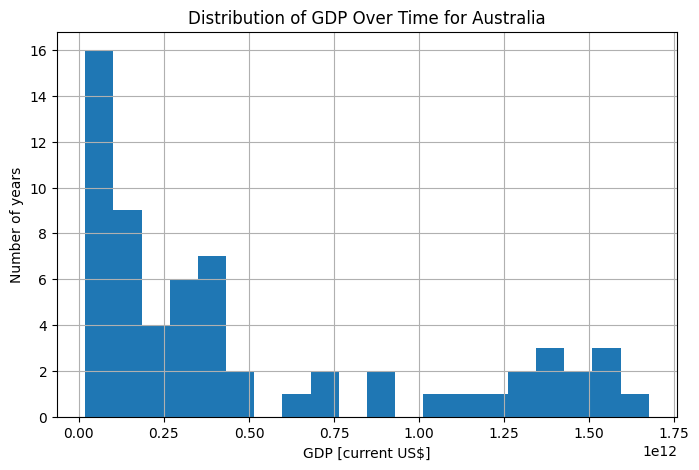

In [15]:
country = "Australia"  # or any country you want

gdp_country = gdp_transposed[country]

plt.figure(figsize=(8, 5))
plt.hist(gdp_country, bins=20)

plt.xlabel("GDP [current US$]")
plt.ylabel("Number of years")
plt.title(f"Distribution of GDP Over Time for {country}")

plt.grid(True)
plt.show()

### Interpreting the Histogram

This histogram shows how GDP values for a country are distributed over time.

- Most values are lower, with fewer high values → the data is **right-skewed**
- This suggests GDP has generally **increased over time**

 However, this plot does not show *when* changes happened.

 For time-based data like GDP, a **line plot is more useful** because it shows trends over time.

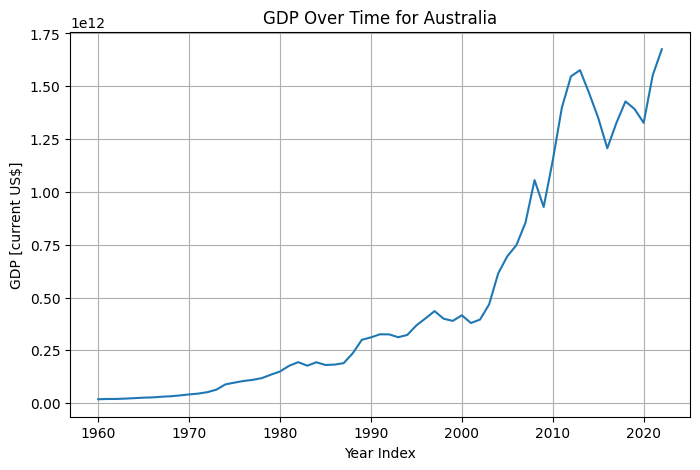

In [16]:
plt.figure(figsize=(8,5))
plt.plot(gdp_country)

plt.xlabel("Year Index")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Over Time for {country}")

plt.grid(True)
plt.show()

## 6. Filtering Data with Masks

Sometimes we only want to look at specific parts of our data.

In Python, we can use **masks** (boolean conditions) to filter data.

For example, we might want to:
- Look at years where GDP is above a certain value
- Focus on periods of rapid growth

Japan, for exmaple, shows relatively consistent growth up to around 1995, as shown below.

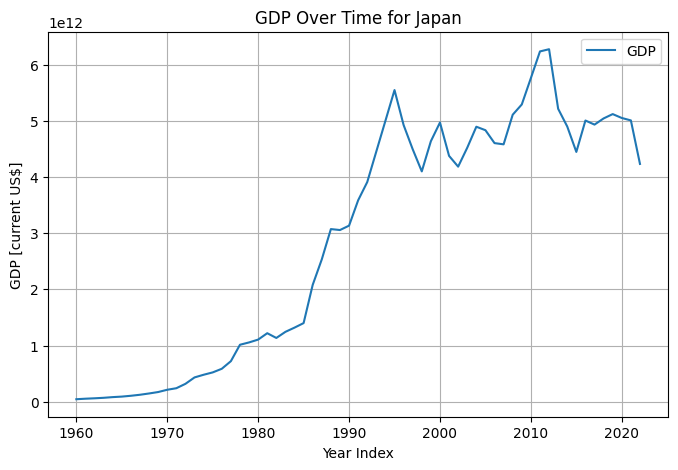

In [17]:
country = "Japan"
gdp_japan = gdp_transposed[country]

plt.figure(figsize=(8,5))
plt.plot(gdp_japan, label="GDP")

plt.xlabel("Year Index")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Over Time for {country}")

plt.legend()
plt.grid(True)
plt.show()

Using a mask, we can isolate specific time periods in the data.

This allows us to focus on particular trends without removing the rest of the dataset.

In [18]:
# Create mask for years before 1995
mask = gdp_japan.index < 1995

gdp_before_1995 = gdp_japan[mask]

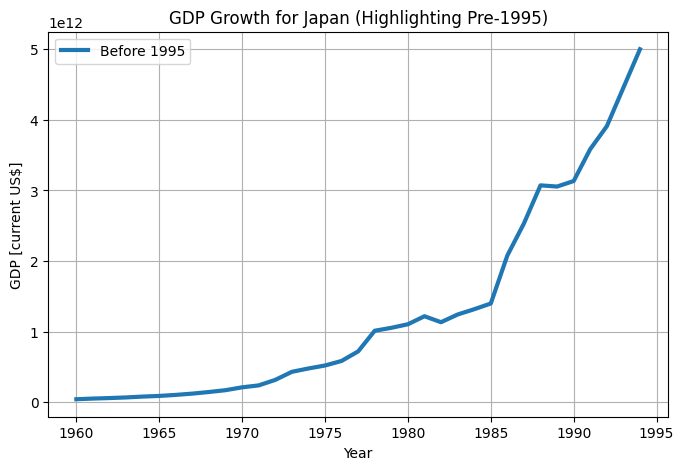

In [19]:
plt.figure(figsize=(8,5))

#plt.plot(gdp_japan, label="All data")
plt.plot(gdp_before_1995, label="Before 1995", linewidth=3)

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Growth for {country} (Highlighting Pre-1995)")

plt.legend()
plt.grid(True)
plt.show()

## 7. Comparing Multiple Countries

Now we will compare GDP over time for several countries.

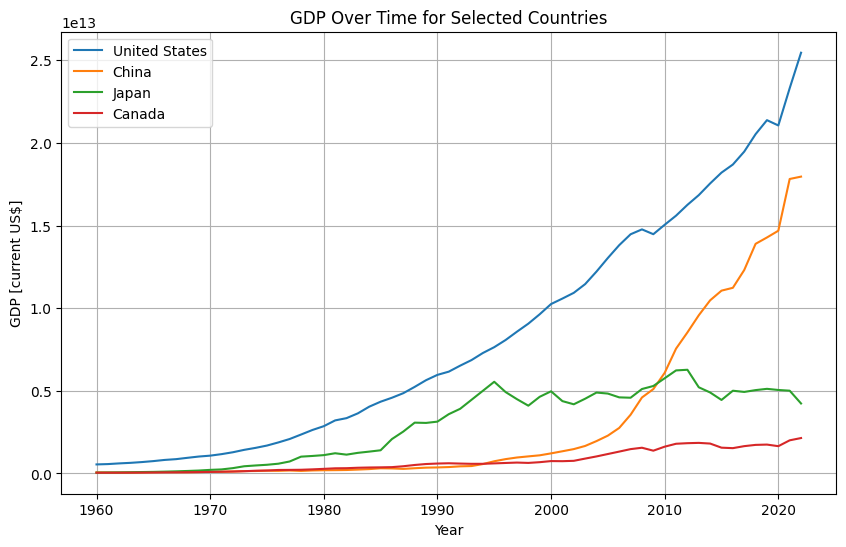

In [20]:
countries = ["United States", "China", "Japan", "Canada"]

years = gdp_transposed.index.astype(int)

plt.figure(figsize=(10, 6))

for country in countries:
    if country not in gdp_transposed.columns:
        print(f"Warning: {country} not found in dataset")
        continue

    gdp_values = gdp_transposed[country].values.astype(float)
    plt.plot(years, gdp_values, label=country)

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title("GDP Over Time for Selected Countries")

plt.legend()
plt.grid(True)
plt.show()

When values are very different in size, a log scale can make comparison easier.

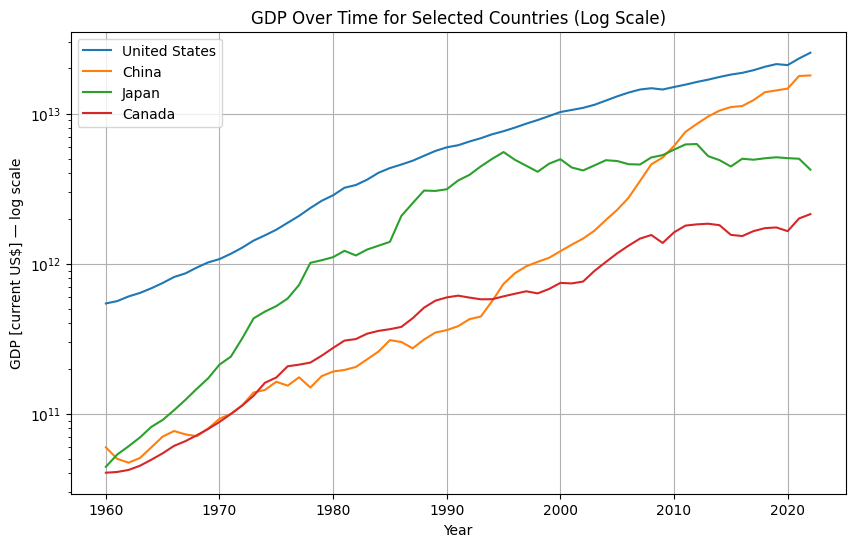

In [21]:
plt.figure(figsize=(10, 6))

for country in countries:
    if country not in gdp_transposed.columns:
        continue

    gdp_values = gdp_transposed[country].values.astype(float)
    plt.plot(years, gdp_values, label=country)

plt.yscale("log")

plt.xlabel("Year")
plt.ylabel("GDP [current US$] — log scale")
plt.title("GDP Over Time for Selected Countries (Log Scale)")

plt.legend()
plt.grid(True)
plt.show()

## 8. Correlation

Correlation measures how strongly two numerical variables are related.

A correlation close to 1 means the variables tend to increase together.

A correlation close to -1 means one variable tends to decrease as the other increases.

A correlation close to 0 means there is not a strong linear relationship.

In [22]:
selected_years = ["2000", "2005", "2010", "2015", "2020", "2022"]

corr_matrix = gdp_clean[selected_years].corr()  # Notice that we are using gdp_clean, which has the original structure with years as columns.

corr_matrix

,2000,2005,2010,2015,2020,2022
2000,1.000000,0.997969,0.972219,0.945335,0.935505,0.921715
2005,0.997969,1.000000,0.982709,0.959609,0.950634,0.938604
2010,0.972219,0.982709,1.000000,0.994042,0.989375,0.984036
2015,0.945335,0.959609,0.994042,1.000000,0.999122,0.997502
2020,0.935505,0.950634,0.989375,0.999122,1.000000,0.999055
2022,0.921715,0.938604,0.984036,0.997502,0.999055,1.000000


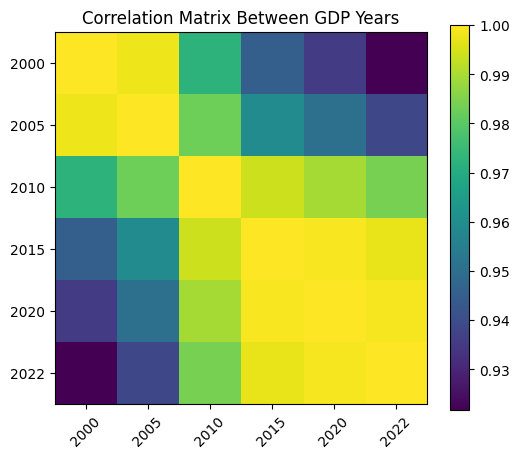

In [23]:
plt.figure(figsize=(6, 5))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(selected_years)), selected_years, rotation=45) 
plt.yticks(range(len(selected_years)), selected_years)
plt.title("Correlation Matrix Between GDP Years")
plt.show()

## 9. Scatter Plots

We can use a scatter plot to compare the GDP of two countries over time.

Each point represents a year:
- x-axis → GDP of Country A
- y-axis → GDP of Country B

If the points follow a clear pattern, it suggests a relationship between their economies.

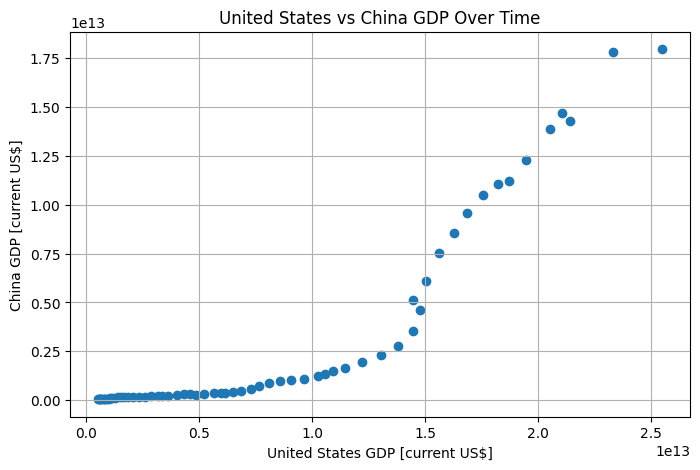

In [24]:
country1 = "United States"
country2 = "China"

gdp_1 = gdp_transposed[country1]
gdp_2 = gdp_transposed[country2]

plt.figure(figsize=(8, 5))
plt.scatter(gdp_1, gdp_2)

plt.xlabel(f"{country1} GDP [current US$]")
plt.ylabel(f"{country2} GDP [current US$]")
plt.title(f"{country1} vs {country2} GDP Over Time")

plt.grid(True)
plt.show()

### Interpretation

Each point is a year.

If the points move upward together, it means both countries’ GDPs are increasing over time.

A clear upward trend suggests a strong relationship between the two economies.

## 10. Introduction to Modeling

A model is a simplified way to describe a relationship in data.

For example, we might ask:

Can we use the year to predict GDP?

This is the basic idea behind machine learning:

Use data to learn a pattern, then use that pattern to make predictions.

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 11. Linear Regression

A linear regression model assumes the data follows a straight-line pattern.

In [ ]:
country_name = "United States"

# X = years
years = gdp_transposed.index.to_numpy() # Convert index to numpy array
X = years.reshape(-1, 1) # Reshape to make it a 2D array with one column, which is required by scikit-learn models

# y = GDP values for selected country
y = gdp_transposed[country_name].values.astype(float) # Convert to float in case there are any non-numeric values

linear_model = LinearRegression()
linear_model.fit(X, y)

y_pred_linear = linear_model.predict(X)

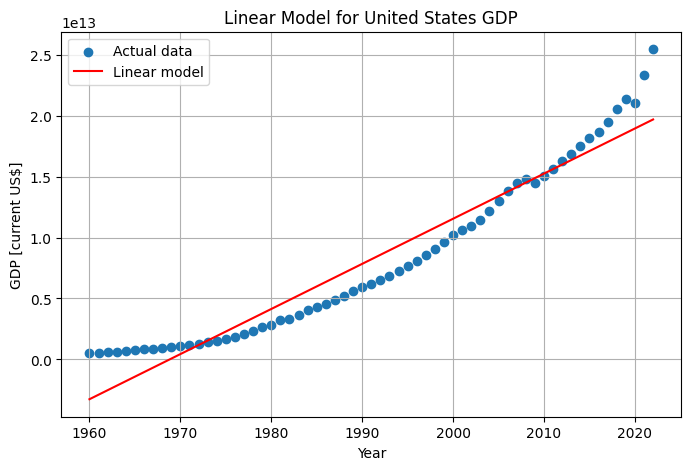

In [27]:
plt.figure(figsize=(8, 5))

plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, color="red", label="Linear model")  # changed color

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Linear Model for {country_name} GDP")

plt.legend()
plt.grid(True)
plt.show()

## 12. Evaluating the Linear Model

We need to measure how well the model fits the data.

Two common metrics are:

- RMSE: average prediction error
- R²: how much variation in the data is explained by the model

In [28]:
rmse_linear = np.sqrt(mean_squared_error(y, y_pred_linear))
r2_linear = r2_score(y, y_pred_linear)

print("Linear RMSE:", rmse_linear)
print("Linear R²:", r2_linear)

Linear RMSE: 1843037678131.5547
Linear R²: 0.930348948642023


## 13. Polynomial Regression

A straight line may not describe the data well.

A polynomial model can curve, so it may fit some patterns better.

In [29]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

poly_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

poly_model.fit(X, y)

y_pred_poly = poly_model.predict(X)

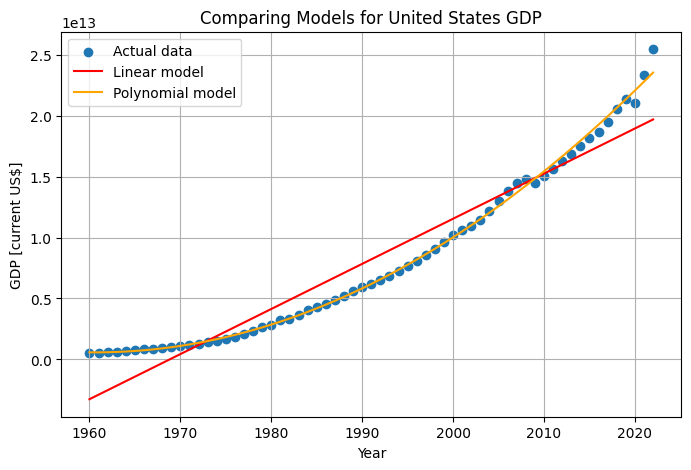

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, color="red", label="Linear model")
plt.plot(years, y_pred_poly, color="orange", label="Polynomial model")
plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Comparing Models for {country_name} GDP")
plt.legend()
plt.grid(True)
plt.show()

## 14. Comparing Models

Now we compare the linear model and the polynomial model using RMSE and R².

In [31]:
rmse_poly = np.sqrt(mean_squared_error(y, y_pred_poly))
r2_poly = r2_score(y, y_pred_poly)

print("Linear RMSE:", rmse_linear)
print("Polynomial RMSE:", rmse_poly)

print("Linear R²:", r2_linear)
print("Polynomial R²:", r2_poly)

Linear RMSE: 1843037678131.5547
Polynomial RMSE: 370864977548.12396
Linear R²: 0.930348948642023
Polynomial R²: 0.9971797286573196


A lower RMSE means the model has smaller prediction errors.

A higher R² usually means the model explains more of the variation in the data.

However, a model that fits old data very well is not always better at predicting new data.

## 15. Making Predictions

Now we can use our models to predict GDP in a future year.

In [32]:
future_year = np.array([[2030]])

linear_prediction = linear_model.predict(future_year)
poly_prediction = poly_model.predict(future_year)

print("Linear model prediction for 2030:", linear_prediction[0])
print("Polynomial model prediction for 2030:", poly_prediction[0])

Linear model prediction for 2030: 22660298340090.875
Polynomial model prediction for 2030: 29928986899212.0


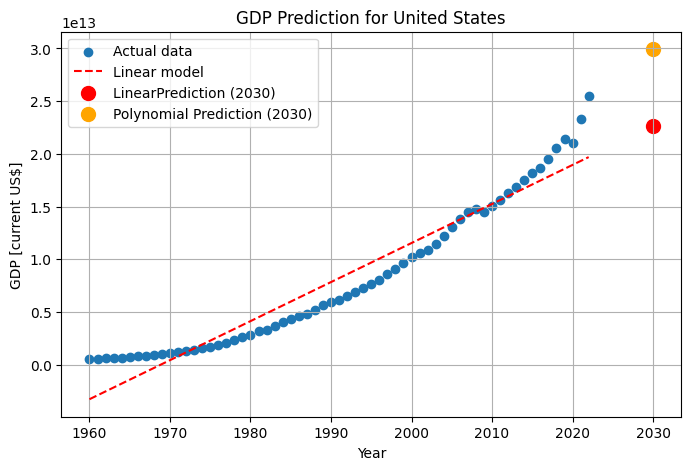

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(years, y, label="Actual data")
plt.plot(years, y_pred_linear, color="red", linestyle="--", label="Linear model")

# Add prediction point
plt.scatter(2030, linear_prediction, color="red", s=100, label="LinearPrediction (2030)")
plt.scatter(2030, poly_prediction, color="orange", s=100, label="Polynomial Prediction (2030)")

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"GDP Prediction for {country_name}")

plt.legend()
plt.grid(True)
plt.show()

### Reflection

- Does the predicted value for 2030 follow the trend shown in the plot?
- Which model (linear or polynomial) seems more realistic? Why?
- What might happen if we try to predict too far into the future?

### Important Idea

When we predict the future using past data, we assume that:
- The same patterns will continue
- No major changes occur 

This is why predictions should always be interpreted carefully.

## 16. Training and Testing

A model can look good on the data it was trained on but perform poorly on new data.

To test this, we can train the model on earlier years and test it on later years.

In [34]:
train_mask = years <= 2010
test_mask = years > 2010

X_train = years[train_mask].reshape(-1, 1)
y_train = y[train_mask]

X_test = years[test_mask].reshape(-1, 1)
y_test = y[test_mask]

In [35]:
test_model = LinearRegression()
test_model.fit(X_train, y_train)

test_predictions = test_model.predict(X_test)

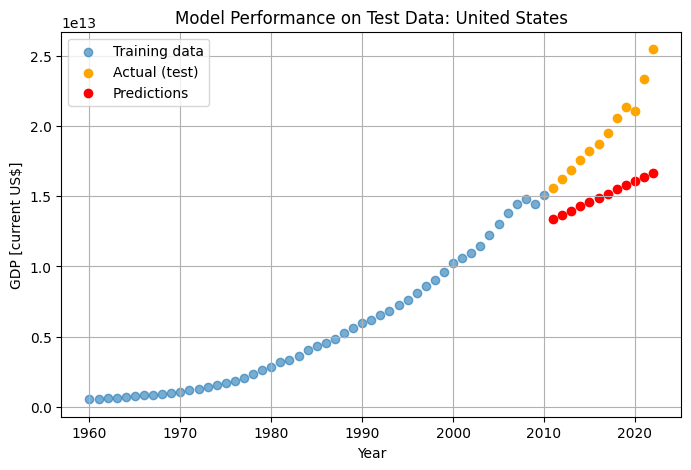

In [36]:
plt.figure(figsize=(8, 5))

# Training data
plt.scatter(X_train, y_train, label="Training data", alpha=0.6)

# Actual test data
plt.scatter(X_test, y_test, color="orange", label="Actual (test)")

# Predicted test data (as dots)
plt.scatter(X_test, test_predictions, color="red", label="Predictions")

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Model Performance on Test Data: {country_name}")

plt.legend()
plt.grid(True)
plt.show()

In [37]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))
test_r2 = r2_score(y_test, test_predictions)

print("Test RMSE:", test_rmse)
print("Test R²:", test_r2)

Test RMSE: 4862482645490.22
Test R²: -1.9534028421591256


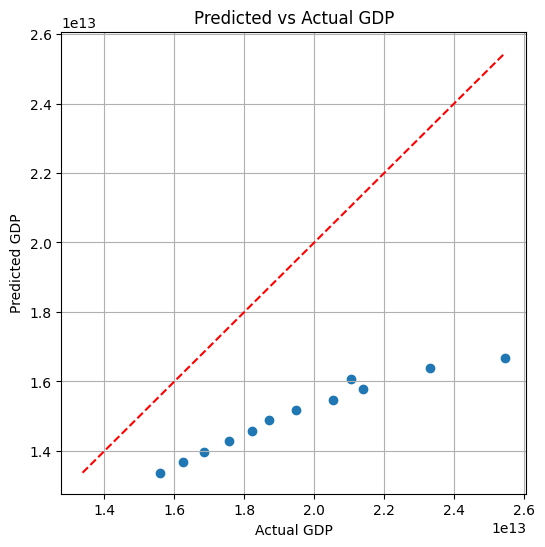

In [38]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, test_predictions)

# Perfect prediction line
min_val = min(y_test.min(), test_predictions.min())
max_val = max(y_test.max(), test_predictions.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--') # Add a dashed red line for perfect predictions

plt.xlabel("Actual GDP")
plt.ylabel("Predicted GDP")
plt.title("Predicted vs Actual GDP")

plt.grid(True)
plt.show()

This is closer to how machine learning models are evaluated.

We do not only care about how well a model fits old data.

We care about how well it predicts new data.

## 17. Your Turn: Model Exploration

Choose any country and try to model its GDP over time.

There is no single correct approach — your goal is to explore and decide what works best.

### Your task:

1. Select a country from `gdp_transposed`
2. Extract the GDP values for that country
3. Create `X` using the years
4. Create `y` using the country’s GDP values

### Now experiment:

- Try a **linear model**
- Try a **polynomial model**
- Optionally, explore other models online

You may also:

- Use a **mask** to focus on a specific time period  
  (for example, specific years where the trend is more consistent)

### Then:

- Fit your model
- Plot the actual data and your model
- Predict GDP for the year 2030

---

### Questions to answer:

1. What country did you choose?
2. What does the GDP trend look like?
3. What model did you use? Why?
4. Did you use the full dataset or a subset (mask)?
5. What does your model predict for 2030?
6. Do you trust your prediction? Why or why not?

In [39]:
# Choose a country
chosen_country = "Japan"

# Step 1: Get the years from gdp_transposed
# X = ...

# Step 2: Get GDP values for the chosen country
# y = ...

# Optional: Apply a mask to focus on a specific time period
# Example: focus on years after 1990
# mask = ...
# X = ...
# y = ...

# Step 3: Choose a model
# You can try:
# - LinearRegression()
# - Polynomial model (PolynomialFeatures + LinearRegression)
# - Or another model if you want to explore

# Example:
# student_model = ...

# Step 4: Fit the model
# student_model.fit(X, y)

# Step 5: Make predictions for the years in the dataset
# student_predictions = ...

# Step 6: Plot the actual data and your model
# plt.figure(figsize=(8,5))
# plt.scatter(..., label="Actual data")
# plt.plot(..., label="Model")
# plt.xlabel("Year")
# plt.ylabel("GDP [current US$]")
# plt.title(f"Model for {chosen_country} GDP")
# plt.legend()
# plt.grid(True)
# plt.show()

# Step 7: Predict GDP in 2030
# future_year = ...
# future_prediction = ...
# print(...)

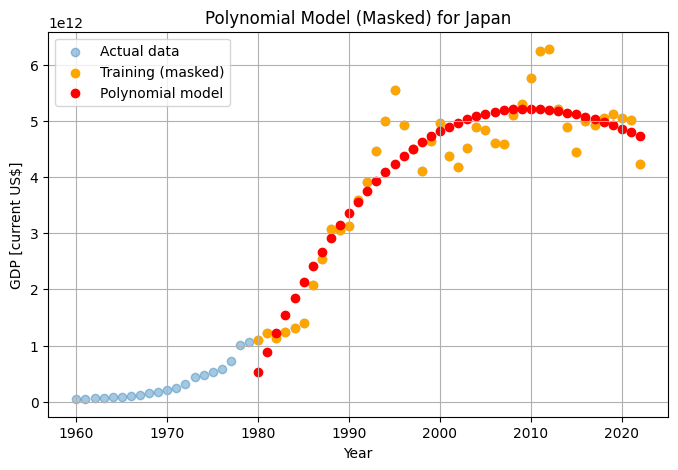

Polynomial model prediction for Japan GDP in 2030: 4056382434560.0


In [40]:
# Delete or don't share this cell to students, as it contains the step-by-step instructions for them to follow when building their own model. You can also modify the instructions as needed to fit the specific learning goals you have for your students. 
# Choose a country
chosen_country = "Japan"

# Step 1: Get years and GDP
years = gdp_transposed.index.to_numpy()
X = years.reshape(-1, 1)
y = gdp_transposed[chosen_country].values.astype(float)

# Step 2: Apply a mask (focus on more stable growth period)
mask = years >= 1980
X_masked = X[mask]
y_masked = y[mask]

# Step 3: Create a polynomial model (degree 3 works well here)
student_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)

# Step 4: Fit the model
student_model.fit(X_masked, y_masked)

# Step 5: Predictions (on masked years for clarity)
student_predictions = student_model.predict(X_masked)

# Step 6: Plot
plt.figure(figsize=(8, 5))

# All actual data
plt.scatter(years, y, label="Actual data", alpha=0.4)

# Masked data used for training
plt.scatter(X_masked, y_masked, label="Training (masked)", color="orange")

# Model prediction
plt.scatter(X_masked, student_predictions, color="red", label="Polynomial model")

plt.xlabel("Year")
plt.ylabel("GDP [current US$]")
plt.title(f"Polynomial Model (Masked) for {chosen_country}")

plt.legend()
plt.grid(True)
plt.show()

# Step 7: Predict GDP in 2030
future_year = np.array([[2030]])
future_prediction = student_model.predict(future_year)

print(f"Polynomial model prediction for {chosen_country} GDP in 2030:", future_prediction[0])

## 18. Optional: Introduction to SVD

Singular Value Decomposition, or SVD, is a method that breaks a dataset into important patterns.

It is often used for:
- Dimensionality reduction
- Compression
- Finding hidden patterns in data
- Preparing data for machine learning

Here, we will apply SVD to the GDP dataset to see if a few patterns can represent most of the data.

In [41]:
# Select only the numerical GDP values
# Rows = years, columns = countries
gdp_matrix = gdp_transposed.values.astype(float)

# Scale the data so very large countries do not dominate too much
gdp_matrix_scaled = (gdp_matrix - gdp_matrix.mean(axis=0)) / gdp_matrix.std(axis=0)

# Replace possible NaN values caused by zero standard deviation
gdp_matrix_scaled = np.nan_to_num(gdp_matrix_scaled)

SVD separates the data matrix into three parts:

\[
X = U \Sigma V^T
\]

The most important values are the singular values. Larger singular values represent stronger patterns in the data.

In [42]:
U, S, Vt = np.linalg.svd(gdp_matrix_scaled, full_matrices=False)

S

array([8.49134311e+01, 1.61454558e+01, 8.97364750e+00, 5.45528193e+00,
       5.10596509e+00, 4.25321508e+00, 3.76996521e+00, 3.34932526e+00,
       2.36483023e+00, 2.07106044e+00, 2.01816994e+00, 1.80909291e+00,
       1.65960458e+00, 1.60502977e+00, 1.42106210e+00, 1.19719982e+00,
       1.13763179e+00, 1.07787849e+00, 9.68493047e-01, 8.80619432e-01,
       7.90455802e-01, 7.46090338e-01, 6.79192286e-01, 6.55811143e-01,
       5.88981157e-01, 5.72112488e-01, 5.49480660e-01, 4.90568764e-01,
       4.73169603e-01, 4.45146550e-01, 4.15519145e-01, 3.84186627e-01,
       3.68106867e-01, 3.34423138e-01, 3.19592923e-01, 2.98983120e-01,
       2.85037155e-01, 2.79972793e-01, 2.65521198e-01, 2.25927317e-01,
       2.08155893e-01, 1.92655438e-01, 1.79541115e-01, 1.59424927e-01,
       1.38181152e-01, 1.23035392e-01, 1.20423579e-01, 1.02035253e-01,
       8.69343886e-02, 7.63921724e-02, 5.68581113e-02, 5.21916891e-02,
       4.97886385e-02, 3.64990697e-02, 3.24308115e-02, 2.73067969e-02,
      

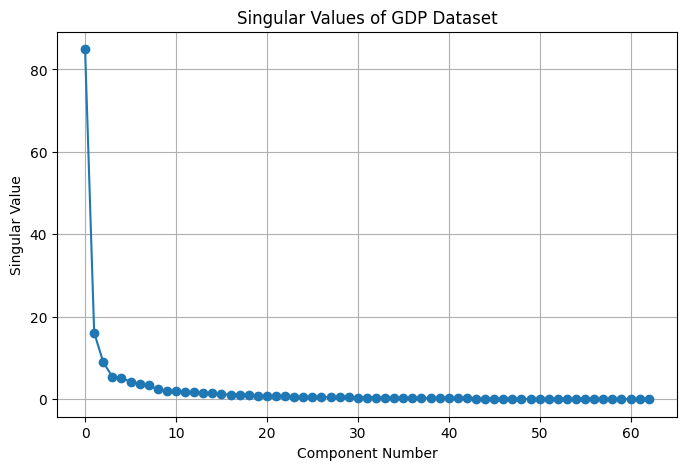

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(S, marker="o")

plt.xlabel("Component Number")
plt.ylabel("Singular Value")
plt.title("Singular Values of GDP Dataset")

plt.grid(True)
plt.show()

### Interpreting the Plot

If the first few singular values are much larger than the rest, then a small number of patterns explain most of the dataset.

This is useful because it means we may not need every original variable to understand the main structure of the data.

In [48]:
# Keep only the first k patterns
k = 5

U_k = U[:, :k]
S_k = np.diag(S[:k])
Vt_k = Vt[:k, :]

gdp_approx = U_k @ S_k @ Vt_k

The reconstructed dataset `gdp_approx` is an approximation of the original data using only the first few SVD components.

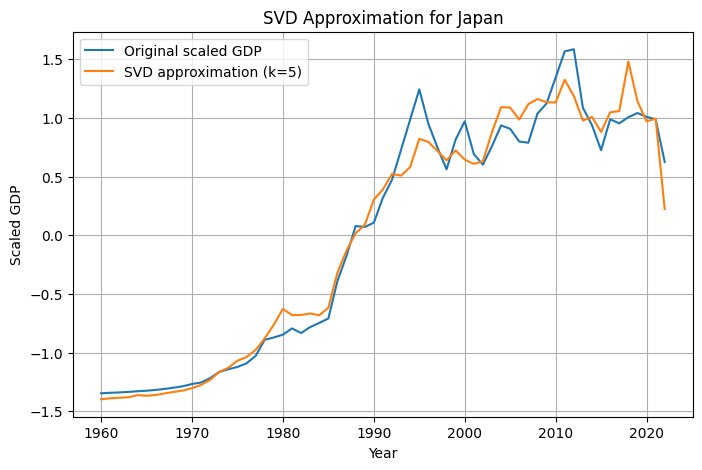

In [49]:
country = "Japan"

country_index = list(gdp_transposed.columns).index(country)

original = gdp_matrix_scaled[:, country_index]
approx = gdp_approx[:, country_index]

plt.figure(figsize=(8, 5))

plt.plot(gdp_transposed.index, original, label="Original scaled GDP")
plt.plot(gdp_transposed.index, approx, label=f"SVD approximation (k={k})")

plt.xlabel("Year")
plt.ylabel("Scaled GDP")
plt.title(f"SVD Approximation for {country}")

plt.legend()
plt.grid(True)
plt.show()

### Key Idea

SVD helps us summarize a large dataset using fewer patterns.

This connects to machine learning because many ML methods work better when data is simplified, compressed, or transformed into more meaningful features.

## Final Reflection

In this notebook, we practiced the basic workflow used in data analysis and machine learning:

1. Load data
2. Inspect data
3. Clean missing values
4. Visualize patterns
5. Look for relationships
6. Filter useful subsets
7. Fit a model
8. Evaluate the model
9. Make predictions
10. Question whether the predictions make sense
11. Introduction to SVD

This workflow is the foundation for more advanced machine learning.